# Analytics Logic

This notebook builds analytics logic for the airport operations platform: fuel cost savings, delay penalty avoidance, resource cost efficiency, turnaround trends, delay causes, delay pattern heatmaps, utilization history, model improvement, and backend-ready analytics payloads.

## 1. Setup

In [1]:
import random
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1200)

now = datetime(2026, 4, 27, 9, 0)

## 2. Analytics Configuration

In [2]:
AIRLINES = ['Air India', 'IndiGo', 'SpiceJet', 'Vistara', 'Akasa', 'AirAsia']
DELAY_CAUSES = ['Gate conflict', 'Fueling overlap', 'Crew positioning', 'Baggage delay', 'ATC slot miss', 'Weather', 'Maintenance', 'Runway queue']
RESOURCE_TYPES = ['Crew', 'Equipment', 'Gates', 'Runways', 'Baggage Belts', 'GPU']
FUEL_PRICE_PER_LITER = 92.5
BASELINE_TAXI_FUEL_LPM = 42
PENALTY_PER_MIN = {'Air India': 520, 'IndiGo': 460, 'SpiceJet': 390, 'Vistara': 540, 'Akasa': 410, 'AirAsia': 360}

## 3. Generate Historical Analytics Dataset

In [3]:
def generate_analytics_history(days=90, flights_per_day=58):
    rows = []
    start = (now - timedelta(days=days)).replace(hour=0, minute=0, second=0, microsecond=0)
    for day in range(days):
        current_date = start + timedelta(days=day)
        weekday = current_date.weekday()
        for f in range(flights_per_day + random.randint(-8, 12)):
            hour = random.choices(range(24), weights=[2,1,1,1,2,4,8,12,11,8,7,6,6,7,8,8,10,13,14,12,8,5,3,2])[0]
            airline = random.choice(AIRLINES)
            peak = hour in [7, 8, 9, 17, 18, 19]
            ai_optimized = random.random() < (0.42 + min(day / days, 1) * 0.38)
            scheduled_tat = random.choice([35, 42, 48, 55, 75, 90])
            base_delay = np.random.gamma(2.0, 7.5) + (10 if peak else 0) + (6 if weekday == 4 else 0)
            if ai_optimized:
                avoided_delay = base_delay * random.uniform(0.22, 0.58)
            else:
                avoided_delay = 0
            actual_delay = max(0, base_delay - avoided_delay + np.random.normal(0, 4))
            baseline_taxi_min = np.clip(np.random.normal(16 + (4 if peak else 0), 5), 6, 35)
            optimized_taxi_min = max(4, baseline_taxi_min - (random.uniform(1.5, 7.0) if ai_optimized else random.uniform(-1, 1)))
            fuel_saved_liters = max(0, (baseline_taxi_min - optimized_taxi_min) * BASELINE_TAXI_FUEL_LPM)
            penalty_avoided = avoided_delay * PENALTY_PER_MIN[airline]
            resource_cost = random.uniform(18000, 90000) * (1.08 if not ai_optimized else 0.94)
            passenger_count = random.randint(55, 410)
            turnaround_actual = scheduled_tat + actual_delay * 0.42 + np.random.normal(0, 5)
            cause = random.choices(DELAY_CAUSES, weights=[18, 15, 15, 14, 10, 10, 8, 10])[0]

            rows.append({
                'date': current_date.date(),
                'timestamp': current_date + timedelta(hours=hour, minutes=random.randint(0, 59)),
                'weekday': weekday,
                'hour': hour,
                'flight_id': f'{random.choice(["AI", "6E", "SG", "UK", "QP"])}{random.randint(100, 999)}',
                'airline': airline,
                'passenger_count': passenger_count,
                'scheduled_turnaround_min': scheduled_tat,
                'actual_turnaround_min': round(turnaround_actual, 1),
                'delay_minutes': round(actual_delay, 1),
                'avoided_delay_minutes': round(avoided_delay, 1),
                'delay_cause': cause,
                'baseline_taxi_min': round(baseline_taxi_min, 1),
                'optimized_taxi_min': round(optimized_taxi_min, 1),
                'fuel_saved_liters': round(fuel_saved_liters, 1),
                'fuel_cost_saved': round(fuel_saved_liters * FUEL_PRICE_PER_LITER, 1),
                'penalty_avoided': round(penalty_avoided, 1),
                'resource_cost': round(resource_cost, 1),
                'ai_optimized': ai_optimized,
                'model_version': f'v{1 + day // 22}.{day % 22}',
            })
    return pd.DataFrame(rows)


history_df = generate_analytics_history()
history_df.head(10)

,date,timestamp,weekday,hour,flight_id,airline,passenger_count,scheduled_turnaround_min,actual_turnaround_min,delay_minutes,avoided_delay_minutes,delay_cause,baseline_taxi_min,optimized_taxi_min,fuel_saved_liters,fuel_cost_saved,penalty_avoided,resource_cost,ai_optimized,model_version
0,2026-01-27,2026-01-27 06:27:00,1,6,AI130,AirAsia,334,42,48.9,12.5,4.9,Gate conflict,10.4,8.4,86.7,8017.6,1746.5,67048.4,True,v1.0
1,2026-01-27,2026-01-27 06:28:00,1,6,QP384,IndiGo,334,35,45.9,19.4,0.0,Crew positioning,13.7,13.5,5.1,475.9,0.0,75117.7,False,v1.0
2,2026-01-27,2026-01-27 18:48:00,1,18,SG204,Air India,134,42,53.8,16.7,0.0,Fueling overlap,6.9,6.5,16.6,1539.5,0.0,45897.9,False,v1.0
3,2026-01-27,2026-01-27 06:59:00,1,6,UK180,Air India,329,48,43.6,6.4,9.7,Gate conflict,11.5,5.5,249.4,23073.8,5046.1,66308.2,True,v1.0
4,2026-01-27,2026-01-27 15:49:00,1,15,SG181,AirAsia,78,48,63.3,31.8,0.0,ATC slot miss,28.8,28.6,6.5,601.0,0.0,74227.5,False,v1.0
5,2026-01-27,2026-01-27 19:44:00,1,19,AI723,Air India,162,55,58.2,11.0,10.6,ATC slot miss,17.0,13.5,147.3,13623.1,5536.5,41973.8,True,v1.0
6,2026-01-27,2026-01-27 16:14:00,1,16,SG963,Akasa,382,42,48.2,14.9,0.0,ATC slot miss,13.3,13.4,0.0,0.0,0.0,40431.1,False,v1.0
7,2026-01-27,2026-01-27 18:20:00,1,18,6E771,Air India,345,35,30.1,11.6,10.4,Maintenance,21.0,17.3,155.7,14399.4,5410.1,21399.6,True,v1.0
8,2026-01-27,2026-01-27 14:37:00,1,14,UK697,AirAsia,330,48,54.2,4.3,0.0,Fueling overlap,17.1,17.8,0.0,0.0,0.0,77370.3,False,v1.0
9,2026-01-27,2026-01-27 12:09:00,1,12,6E911,IndiGo,79,42,47.3,0.0,0.0,Maintenance,13.7,13.7,0.8,74.0,0.0,26509.1,False,v1.0


## 4. KPI Calculations

In [4]:
def period_filter(df, days):
    cutoff = now.date() - timedelta(days=days)
    return df[df['date'] >= cutoff]


def build_analytics_kpis(df):
    total_fuel_saved = df['fuel_cost_saved'].sum()
    penalty_avoided = df['penalty_avoided'].sum()
    avg_turnaround = df['actual_turnaround_min'].mean()
    optimized = df[df['ai_optimized']]
    manual = df[~df['ai_optimized']]
    optimized_turnaround = optimized['actual_turnaround_min'].mean() if len(optimized) else avg_turnaround
    manual_turnaround = manual['actual_turnaround_min'].mean() if len(manual) else avg_turnaround
    turnaround_improvement = manual_turnaround - optimized_turnaround
    delay_lift = manual['delay_minutes'].mean() - optimized['delay_minutes'].mean() if len(optimized) and len(manual) else df['avoided_delay_minutes'].mean()
    ai_coverage = df['ai_optimized'].mean() * 100
    total_delay_avoided = df['avoided_delay_minutes'].sum()
    avg_resource_cost_per_flight = df['resource_cost'].mean()
    cost_per_passenger = df['resource_cost'].sum() / max(df['passenger_count'].sum(), 1)
    on_time_rate = (df['delay_minutes'] <= 5).mean() * 100

    return pd.DataFrame([{
        'flights_analyzed': len(df),
        'fuel_cost_saved': int(total_fuel_saved),
        'delay_penalty_avoided': int(penalty_avoided),
        'avg_turnaround_min': round(avg_turnaround, 1),
        'turnaround_improvement_min': round(turnaround_improvement, 1),
        'delay_minutes_avoided': int(total_delay_avoided),
        'delay_reduction_vs_manual_min': round(delay_lift, 1),
        'ai_coverage_pct': round(ai_coverage, 1),
        'avg_resource_cost_per_flight': int(avg_resource_cost_per_flight),
        'resource_cost_per_passenger': round(cost_per_passenger, 1),
        'on_time_rate_pct': round(on_time_rate, 1),
    }])


current_7d = period_filter(history_df, 7)
previous_7d = history_df[(history_df['date'] < now.date() - timedelta(days=7)) & (history_df['date'] >= now.date() - timedelta(days=14))]
kpi_df = build_analytics_kpis(current_7d)
previous_kpi_df = build_analytics_kpis(previous_7d)
kpi_df


,flights_analyzed,fuel_cost_saved,delay_penalty_avoided,avg_turnaround_min,turnaround_improvement_min,delay_minutes_avoided,delay_reduction_vs_manual_min,ai_coverage_pct,avg_resource_cost_per_flight,resource_cost_per_passenger,on_time_rate_pct
0,406,5062654,1103745,63.6,8.1,2461,7.9,77.6,52726,226.4,14.0


## 5. Trend Analytics

In [5]:
def build_daily_trends(df):
    daily = df.groupby('date').agg(
        flights=('flight_id', 'count'),
        avg_turnaround_min=('actual_turnaround_min', 'mean'),
        avg_delay_min=('delay_minutes', 'mean'),
        fuel_cost_saved=('fuel_cost_saved', 'sum'),
        penalty_avoided=('penalty_avoided', 'sum'),
        delay_minutes_avoided=('avoided_delay_minutes', 'sum'),
        ai_coverage_pct=('ai_optimized', lambda x: x.mean() * 100),
        on_time_rate_pct=('delay_minutes', lambda x: (x <= 5).mean() * 100),
    ).reset_index()
    numeric = daily.select_dtypes(include=[np.number]).columns
    daily[numeric] = daily[numeric].round(1)
    return daily


daily_trends_df = build_daily_trends(history_df)
daily_trends_df.tail(14)

,date,flights,avg_turnaround_min,avg_delay_min,fuel_cost_saved,penalty_avoided,delay_minutes_avoided,ai_coverage_pct,on_time_rate_pct
76,2026-04-13,60,60.1,12.8,679093.8,118733.2,270.4,71.7,18.3
77,2026-04-14,54,62.4,12.7,694031.5,138038.2,304.2,72.2,16.7
78,2026-04-15,66,62.5,13.8,702553.0,175069.6,390.6,68.2,18.2
79,2026-04-16,65,63.9,13.0,809289.9,145411.5,330.9,75.4,23.1
80,2026-04-17,55,66.4,19.1,589628.7,154972.2,341.2,63.6,12.7
81,2026-04-18,64,64.7,12.4,767978.5,123029.7,272.0,67.2,15.6
82,2026-04-19,69,66.4,13.2,883014.8,158039.9,362.4,72.5,18.8
83,2026-04-20,62,63.6,12.8,711659.1,160668.0,365.0,69.4,17.7
84,2026-04-21,51,62.6,13.6,618019.0,143909.6,307.5,82.4,15.7
85,2026-04-22,55,58.6,14.2,703817.3,183987.2,401.2,80.0,9.1


## 6. Delay Cause Analytics

In [6]:
def build_delay_cause_table(df):
    cause = df.groupby('delay_cause').agg(
        flights=('flight_id', 'count'),
        avg_delay_min=('delay_minutes', 'mean'),
        total_delay_min=('delay_minutes', 'sum'),
        avoided_delay_min=('avoided_delay_minutes', 'sum'),
        penalty_avoided=('penalty_avoided', 'sum'),
    ).reset_index()
    cause['share_pct'] = (cause['flights'] / cause['flights'].sum() * 100).round(1)
    cause['avg_delay_min'] = cause['avg_delay_min'].round(1)
    cause['total_delay_min'] = cause['total_delay_min'].round(1)
    cause['avoided_delay_min'] = cause['avoided_delay_min'].round(1)
    cause['penalty_avoided'] = cause['penalty_avoided'].round(0).astype(int)
    return cause.sort_values('total_delay_min', ascending=False).reset_index(drop=True)


delay_causes_df = build_delay_cause_table(current_7d)
delay_causes_df

,delay_cause,flights,avg_delay_min,total_delay_min,avoided_delay_min,penalty_avoided,share_pct
0,Fueling overlap,80,13.2,1052.7,488.9,212106,19.7
1,Baggage delay,61,16.1,979.4,399.5,178890,15.0
2,Gate conflict,70,13.4,935.9,472.4,213538,17.2
3,Crew positioning,56,14.4,806.9,279.3,126496,13.8
4,ATC slot miss,34,15.7,532.6,184.2,82168,8.4
5,Weather,38,12.2,465.2,215.1,102111,9.4
6,Maintenance,36,12.8,461.9,252.1,111910,8.9
7,Runway queue,31,14.1,437.5,169.6,76527,7.6


## 7. Delay Pattern Heatmap

In [7]:
def build_delay_heatmap(df):
    heat = df[df['delay_minutes'] > 5].groupby(['weekday', 'hour']).size().reset_index(name='delay_count')
    matrix = heat.pivot(index='weekday', columns='hour', values='delay_count').reindex(index=range(7), columns=range(24), fill_value=0).fillna(0).astype(int)
    matrix.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    return matrix


delay_heatmap_df = build_delay_heatmap(current_7d)
delay_heatmap_df.iloc[:, 6:22]

hour,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21
Mon,0,3,6,3,3,6,1,1,1,1,3,3,6,3,2,0
Tue,1,6,4,1,1,1,1,1,2,3,4,6,1,4,1,2
Wed,2,2,6,3,1,3,3,2,3,0,6,5,4,4,1,2
Thu,2,4,3,2,2,2,1,0,3,1,1,0,4,6,4,1
Fri,8,5,0,4,1,1,1,2,7,3,1,7,4,8,2,1
Sat,3,5,2,1,1,0,2,6,6,2,5,7,5,4,3,3
Sun,3,3,5,2,5,2,0,1,2,2,3,4,1,2,4,0


## 8. Resource Utilization History

In [8]:
def generate_resource_utilization(daily_trends):
    rows = []
    for _, day in daily_trends.iterrows():
        peak_factor = min(day['flights'] / 65, 1.4)
        for resource in RESOURCE_TYPES:
            base = {'Crew': 76, 'Equipment': 73, 'Gates': 82, 'Runways': 65, 'Baggage Belts': 70, 'GPU': 68}[resource]
            utilization = np.clip(np.random.normal(base * peak_factor, 8), 20, 100)
            idle_hours = max(0, (100 - utilization) / 100 * random.uniform(20, 95))
            rows.append({
                'date': day['date'],
                'resource_type': resource,
                'utilization_pct': round(utilization, 1),
                'idle_hours': round(idle_hours, 1),
                'overload_flag': utilization >= 92,
            })
    return pd.DataFrame(rows)


resource_history_df = generate_resource_utilization(daily_trends_df)
resource_summary_df = resource_history_df[resource_history_df['date'].isin(current_7d['date'].unique())].groupby('resource_type').agg(
    avg_utilization_pct=('utilization_pct', 'mean'),
    max_utilization_pct=('utilization_pct', 'max'),
    total_idle_hours=('idle_hours', 'sum'),
    overload_days=('overload_flag', 'sum'),
).reset_index()
resource_summary_df[['avg_utilization_pct', 'max_utilization_pct', 'total_idle_hours']] = resource_summary_df[['avg_utilization_pct', 'max_utilization_pct', 'total_idle_hours']].round(1)
resource_summary_df

,resource_type,avg_utilization_pct,max_utilization_pct,total_idle_hours,overload_days
0,Baggage Belts,64.4,86.9,109.5,0
1,Crew,70.9,89.9,124.7,0
2,Equipment,63.9,75.4,121.7,0
3,GPU,63.8,79.0,140.8,0
4,Gates,70.6,93.0,108.6,1
5,Runways,58.1,75.9,163.0,0


## 9. Model Improvement Log

In [9]:
def build_model_improvement_log(df):
    weekly = df.copy()
    weekly['week'] = pd.to_datetime(weekly['date']).dt.isocalendar().week.astype(int)

    def summarize_week(group):
        ai_group = group[group['ai_optimized']]
        manual_group = group[~group['ai_optimized']]
        ai_coverage_pct = group['ai_optimized'].mean() * 100
        avg_delay = group['delay_minutes'].mean()
        avg_avoided = group['avoided_delay_minutes'].mean()
        ai_delay = ai_group['delay_minutes'].mean() if len(ai_group) else avg_delay
        manual_delay = manual_group['delay_minutes'].mean() if len(manual_group) else avg_delay
        ai_on_time = (ai_group['delay_minutes'] <= 5).mean() * 100 if len(ai_group) else (group['delay_minutes'] <= 5).mean() * 100
        manual_on_time = (manual_group['delay_minutes'] <= 5).mean() * 100 if len(manual_group) else ai_on_time
        delay_lift = manual_delay - ai_delay
        accuracy_proxy = np.clip(80 + delay_lift * 2.6 + (ai_on_time - manual_on_time) * 0.30 + ai_coverage_pct * 0.08, 74, 98)
        rule_updates = max(1, int(round(max(delay_lift, 0) + ai_coverage_pct / 25)))
        return pd.Series({
            'flights': int(group['flight_id'].count()),
            'ai_coverage_pct': round(ai_coverage_pct, 1),
            'avg_delay': round(avg_delay, 1),
            'avg_avoided': round(avg_avoided, 1),
            'model_accuracy_pct': round(float(accuracy_proxy), 1),
            'rule_updates': rule_updates,
            'delay_lift_vs_manual': round(delay_lift, 1),
        })

    model_log = weekly.groupby('week').apply(summarize_week, include_groups=False).reset_index().sort_values('week')
    model_log['milestone'] = model_log.apply(
        lambda row: f"Week {int(row['week'])}: proxy accuracy {row['model_accuracy_pct']}%, delay lift {row['delay_lift_vs_manual']} min, {int(row['rule_updates'])} rules updated",
        axis=1,
    )
    return model_log


model_log_df = build_model_improvement_log(history_df)
model_log_df.tail(10)


,week,flights,ai_coverage_pct,avg_delay,avg_avoided,model_accuracy_pct,rule_updates,delay_lift_vs_manual,milestone
3,8,405.0,55.3,16.4,4.4,98.0,11.0,8.7,"Week 8: proxy accuracy 98.0%, delay lift 8.7 m..."
4,9,458.0,50.7,16.1,4.0,98.0,10.0,8.1,"Week 9: proxy accuracy 98.0%, delay lift 8.1 m..."
5,10,408.0,57.8,16.3,4.6,98.0,12.0,9.8,"Week 10: proxy accuracy 98.0%, delay lift 9.8 ..."
6,11,422.0,61.1,15.7,4.9,98.0,11.0,9.1,"Week 11: proxy accuracy 98.0%, delay lift 9.1 ..."
7,12,431.0,60.6,15.0,4.9,98.0,10.0,7.7,"Week 12: proxy accuracy 98.0%, delay lift 7.7 ..."
8,13,408.0,69.6,15.3,5.6,98.0,11.0,7.8,"Week 13: proxy accuracy 98.0%, delay lift 7.8 ..."
9,14,428.0,67.8,14.7,5.6,98.0,9.0,5.8,"Week 14: proxy accuracy 98.0%, delay lift 5.8 ..."
10,15,430.0,71.4,15.1,5.7,98.0,12.0,9.3,"Week 15: proxy accuracy 98.0%, delay lift 9.3 ..."
11,16,433.0,70.2,13.8,5.2,98.0,9.0,5.9,"Week 16: proxy accuracy 98.0%, delay lift 5.9 ..."
12,17,406.0,77.6,14.0,6.1,98.0,11.0,7.9,"Week 17: proxy accuracy 98.0%, delay lift 7.9 ..."


## 10. Analytics Insights and Recommendations

In [10]:
def build_analytics_recommendations(kpis, causes, heatmap, resources, model_log):
    recs = []
    top_cause = causes.iloc[0]
    recs.append({
        'priority_rank': 1,
        'type': 'delay_cause',
        'severity': 'High',
        'message': f"{top_cause['delay_cause']} is the largest delay contributor with {top_cause['total_delay_min']} minutes.",
        'recommendation': 'Add targeted mitigation rule and monitor impact next 7 days.',
    })

    peak_day = heatmap.sum(axis=1).idxmax()
    peak_hour = int(heatmap.sum(axis=0).idxmax())
    recs.append({
        'priority_rank': 2,
        'type': 'delay_heatmap',
        'severity': 'Medium',
        'message': f"Peak delay pattern occurs on {peak_day} around {peak_hour}:00.",
        'recommendation': 'Pre-position crew, equipment, and gate buffers before this demand wave.',
    })

    overloaded = resources.sort_values('avg_utilization_pct', ascending=False).head(1).iloc[0]
    recs.append({
        'priority_rank': 2,
        'type': 'resource_utilization',
        'severity': 'Medium' if overloaded['avg_utilization_pct'] < 90 else 'High',
        'message': f"{overloaded['resource_type']} average utilization is {overloaded['avg_utilization_pct']}%.",
        'recommendation': 'Balance demand using adjacent terminal capacity or reserve resource pool.',
    })

    latest_model = model_log.sort_values('week').iloc[-1]
    recs.append({
        'priority_rank': 3 if latest_model['model_accuracy_pct'] >= 88 else 2,
        'type': 'model_improvement',
        'severity': 'Low' if latest_model['model_accuracy_pct'] >= 88 else 'Medium',
        'message': latest_model['milestone'],
        'recommendation': 'Promote latest model if shadow evaluation remains stable for 48 hours.' if latest_model['model_accuracy_pct'] >= 88 else 'Recalibrate the model on low-lift segments before the next promotion.',
    })

    if kpis.iloc[0]['turnaround_improvement_min'] < 4:
        recs.append({
            'priority_rank': 2,
            'type': 'turnaround_trend',
            'severity': 'Medium',
            'message': 'Turnaround improvement is below target threshold.',
            'recommendation': 'Review parallel task sequencing for cleaning, fueling, baggage, and boarding.',
        })

    if kpis.iloc[0]['delay_reduction_vs_manual_min'] < 2:
        recs.append({
            'priority_rank': 1,
            'type': 'ai_effectiveness',
            'severity': 'High',
            'message': 'AI-optimized flights are not materially outperforming manual handling this week.',
            'recommendation': 'Inspect model segments by airline and peak hour, then tighten the worst-performing rules.',
        })

    return pd.DataFrame(recs).sort_values(['priority_rank', 'severity']).reset_index(drop=True)


recommendations_df = build_analytics_recommendations(kpi_df, delay_causes_df, delay_heatmap_df, resource_summary_df, model_log_df)
recommendations_df


,priority_rank,type,severity,message,recommendation
0,1,delay_cause,High,Fueling overlap is the largest delay contribut...,Add targeted mitigation rule and monitor impac...
1,2,delay_heatmap,Medium,Peak delay pattern occurs on Sat around 17:00.,"Pre-position crew, equipment, and gate buffers..."
2,2,resource_utilization,Medium,Crew average utilization is 70.9%.,Balance demand using adjacent terminal capacit...
3,3,model_improvement,Low,"Week 17: proxy accuracy 98.0%, delay lift 7.9 ...",Promote latest model if shadow evaluation rema...


## 11. Period Comparison

In [11]:
def compare_periods(current, previous):
    rows = []
    for col in current.columns:
        cur = current.iloc[0][col]
        prev = previous.iloc[0][col] if col in previous.columns else np.nan
        if isinstance(cur, (int, float, np.integer, np.floating)) and pd.notna(prev):
            delta = cur - prev
            pct = (delta / prev * 100) if prev else np.nan
            rows.append({'metric': col, 'current': cur, 'previous': prev, 'delta': round(delta, 1), 'delta_pct': round(pct, 1) if pd.notna(pct) else np.nan})
    return pd.DataFrame(rows)


period_comparison_df = compare_periods(kpi_df, previous_kpi_df)
period_comparison_df

,metric,current,previous,delta,delta_pct
0,flights_analyzed,406.0,433.0,-27.0,-6.2
1,fuel_cost_saved,5062654.0,5125590.0,-62936.0,-1.2
2,delay_penalty_avoided,1103745.0,1013294.0,90451.0,8.9
3,avg_turnaround_min,63.6,63.8,-0.2,-0.3
4,turnaround_improvement_min,8.1,6.0,2.1,35.0
5,delay_minutes_avoided,2461.0,2271.0,190.0,8.4
6,delay_reduction_vs_manual_min,7.9,5.9,2.0,33.9
7,ai_coverage_pct,77.6,70.2,7.4,10.5
8,avg_resource_cost_per_flight,52726.0,52591.0,135.0,0.3
9,resource_cost_per_passenger,226.4,223.9,2.5,1.1


## 12. Analytics Visuals

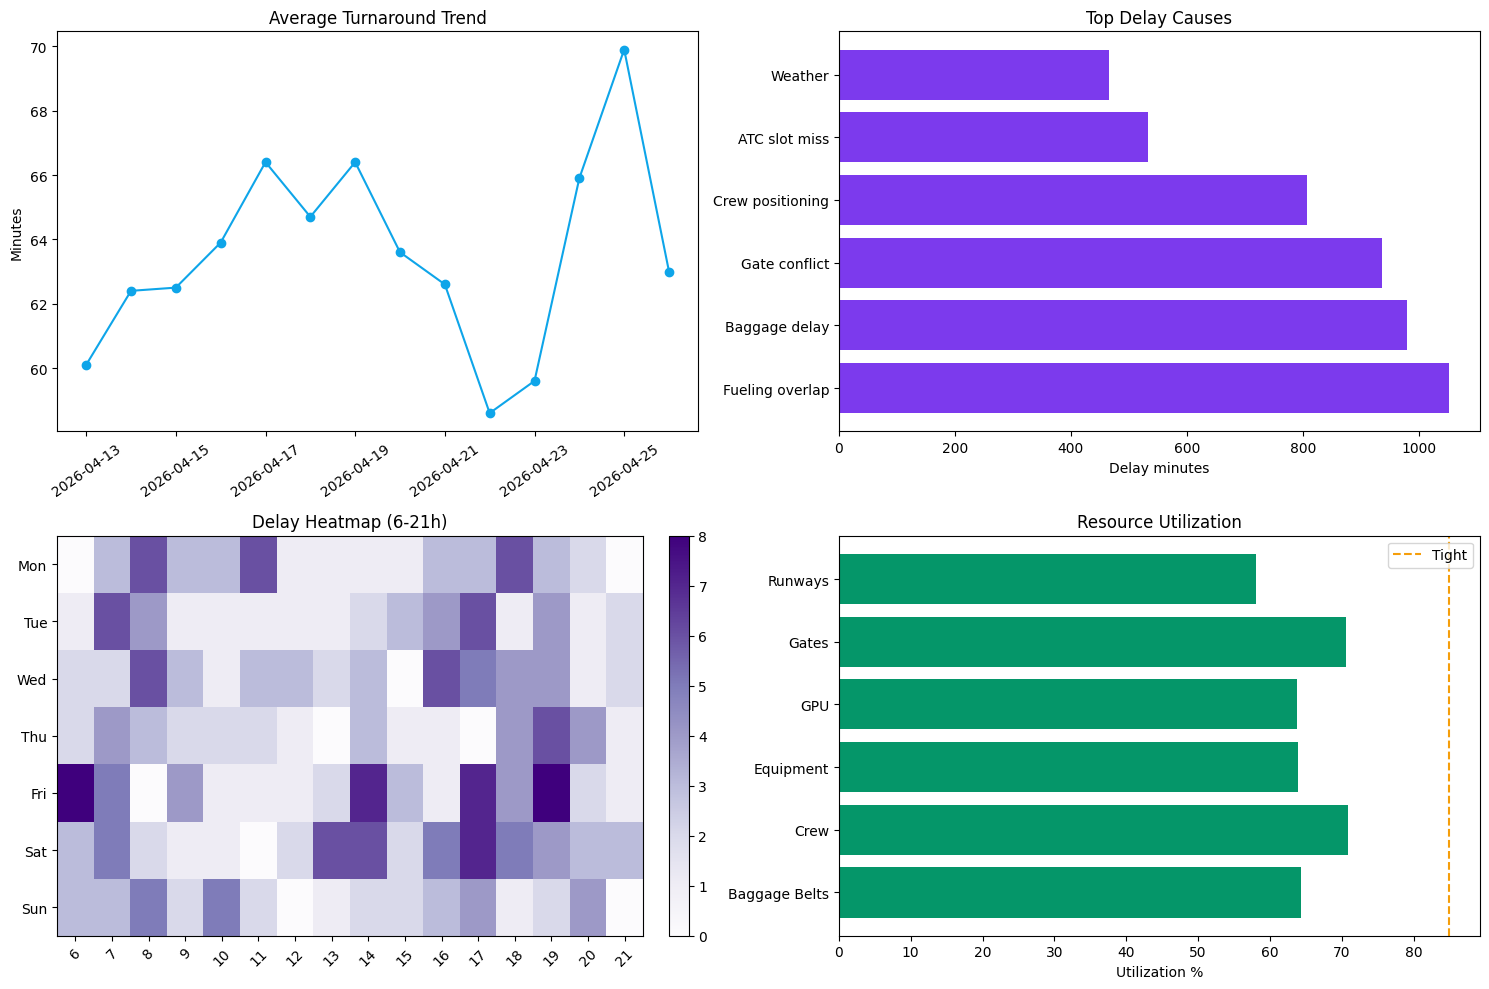

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

recent_daily = daily_trends_df.tail(14)
axes[0, 0].plot(pd.to_datetime(recent_daily['date']), recent_daily['avg_turnaround_min'], marker='o', color='#0ea5e9')
axes[0, 0].set_title('Average Turnaround Trend')
axes[0, 0].tick_params(axis='x', rotation=35)
axes[0, 0].set_ylabel('Minutes')

top_causes = delay_causes_df.head(6)
axes[0, 1].barh(top_causes['delay_cause'], top_causes['total_delay_min'], color='#7c3aed')
axes[0, 1].set_title('Top Delay Causes')
axes[0, 1].set_xlabel('Delay minutes')

heat = delay_heatmap_df.iloc[:, 6:22]
im = axes[1, 0].imshow(heat.values, aspect='auto', cmap='Purples')
axes[1, 0].set_title('Delay Heatmap (6-21h)')
axes[1, 0].set_yticks(range(len(heat.index)))
axes[1, 0].set_yticklabels(heat.index)
axes[1, 0].set_xticks(range(len(heat.columns)))
axes[1, 0].set_xticklabels(heat.columns, rotation=45)
plt.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].barh(resource_summary_df['resource_type'], resource_summary_df['avg_utilization_pct'], color='#059669')
axes[1, 1].axvline(85, color='#f59e0b', linestyle='--', label='Tight')
axes[1, 1].set_title('Resource Utilization')
axes[1, 1].set_xlabel('Utilization %')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 13. Backend-Ready Payload

In [13]:
def build_analytics_payload(kpis, comparison, daily, causes, heatmap, resources, model_log, recommendations):
    return {
        'generated_at': now.isoformat(),
        'kpis': kpis.iloc[0].to_dict(),
        'period_comparison': comparison.to_dict(orient='records'),
        'turnaround_trend': daily.tail(30).assign(date=lambda df: df['date'].astype(str)).to_dict(orient='records'),
        'top_delay_causes': causes.to_dict(orient='records'),
        'delay_heatmap': {
            'days': heatmap.index.tolist(),
            'hours': heatmap.columns.tolist(),
            'matrix': heatmap.values.tolist(),
        },
        'resource_utilization_history': resources.to_dict(orient='records'),
        'model_improvement_log': model_log.tail(12).to_dict(orient='records'),
        'recommendations': recommendations.to_dict(orient='records'),
    }


payload = build_analytics_payload(kpi_df, period_comparison_df, daily_trends_df, delay_causes_df, delay_heatmap_df, resource_summary_df, model_log_df, recommendations_df)
payload

{'generated_at': '2026-04-27T09:00:00',
 'kpis': {'flights_analyzed': 406.0,
  'fuel_cost_saved': 5062654.0,
  'delay_penalty_avoided': 1103745.0,
  'avg_turnaround_min': 63.6,
  'turnaround_improvement_min': 8.1,
  'delay_minutes_avoided': 2461.0,
  'delay_reduction_vs_manual_min': 7.9,
  'ai_coverage_pct': 77.6,
  'avg_resource_cost_per_flight': 52726.0,
  'resource_cost_per_passenger': 226.4,
  'on_time_rate_pct': 14.0},
 'period_comparison': [{'metric': 'flights_analyzed',
   'current': 406.0,
   'previous': 433.0,
   'delta': -27.0,
   'delta_pct': -6.2},
  {'metric': 'fuel_cost_saved',
   'current': 5062654.0,
   'previous': 5125590.0,
   'delta': -62936.0,
   'delta_pct': -1.2},
  {'metric': 'delay_penalty_avoided',
   'current': 1103745.0,
   'previous': 1013294.0,
   'delta': 90451.0,
   'delta_pct': 8.9},
  {'metric': 'avg_turnaround_min',
   'current': 63.6,
   'previous': 63.8,
   'delta': -0.2,
   'delta_pct': -0.3},
  {'metric': 'turnaround_improvement_min',
   'current':

In [14]:
print('ANALYTICS SUMMARY')
print('=================')
print(f"Flights analyzed: {payload['kpis']['flights_analyzed']}")
print(f"Fuel cost saved: Rs {payload['kpis']['fuel_cost_saved']:,}")
print(f"Delay penalty avoided: Rs {payload['kpis']['delay_penalty_avoided']:,}")
print(f"Average turnaround: {payload['kpis']['avg_turnaround_min']} min")
print(f"Delay minutes avoided: {payload['kpis']['delay_minutes_avoided']:,}")
print(f"AI coverage: {payload['kpis']['ai_coverage_pct']}%")
print('\nTop analytics recommendations:')
for item in payload['recommendations'][:5]:
    print(f"- [{item['type']}] {item['message']} {item['recommendation']}")

ANALYTICS SUMMARY
Flights analyzed: 406.0
Fuel cost saved: Rs 5,062,654.0
Delay penalty avoided: Rs 1,103,745.0
Average turnaround: 63.6 min
Delay minutes avoided: 2,461.0
AI coverage: 77.6%

Top analytics recommendations:
- [delay_cause] Fueling overlap is the largest delay contributor with 1052.7 minutes. Add targeted mitigation rule and monitor impact next 7 days.
- [delay_heatmap] Peak delay pattern occurs on Sat around 17:00. Pre-position crew, equipment, and gate buffers before this demand wave.
- [resource_utilization] Crew average utilization is 70.9%. Balance demand using adjacent terminal capacity or reserve resource pool.
- [model_improvement] Week 17: proxy accuracy 98.0%, delay lift 7.9 min, 11 rules updated Promote latest model if shadow evaluation remains stable for 48 hours.
